In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('IMDB Dataset.csv')

In [9]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [11]:
df=df.head(10000)

In [12]:
import nltk
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


In [13]:
sw=set(stopwords.words('english'))

In [14]:
lemma=WordNetLemmatizer()

In [15]:
def preprocess(text):
    review=re.sub(r'[^a-z\s]',' ',text)
    review=review.lower()
    words=review.split()
    words = [lemma.lemmatize(w) for w in words if w not in sw]
    return ' '.join(words)

In [16]:
df['clean_review']=df['review'].apply(preprocess)

/tmp/ipykernel_32469/782437698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_review']=df['review'].apply(preprocess)


In [17]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable


In [18]:
from textblob import TextBlob

In [19]:
def sentiment(text):
    polarity=TextBlob(text).sentiment.polarity
    if polarity>0.1:
        return "positive"
    elif polarity<-0.1:
        return "negative"
    else:
        return "neutral"

In [20]:
df['pred_sen']=df['clean_review'].apply(sentiment)

/tmp/ipykernel_32469/2491425086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pred_sen']=df['clean_review'].apply(sentiment)


In [21]:
df

,review,sentiment,clean_review,pred_sen
0,One of the other reviewers has mentioned that ...,positive,ne reviewer mentioned watching z episode hooke...,neutral
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,positive
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,negative,asically family little boy ake think zombie cl...,neutral
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,etter attei ove ime oney visually stunning fil...,positive
...,...,...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive,un entertaining movie erman spy ulie ndrews fa...,positive
9996,Give me a break. How can anyone say that this ...,negative,ive break ow anyone say good hockey movie know...,neutral
9997,This movie is a bad movie. But after watching ...,negative,movie bad movie ut watching endless series bad...,neutral
9998,This is a movie that was probably made to ente...,negative,movie probably made entertain middle school ea...,neutral


In [22]:
!pip install rake_nltk

Defaulting to user installation because normal site-packages is not writeable


In [23]:
from collections import Counter
from rake_nltk import Rake

In [24]:
rake=Rake()

In [25]:
def ex_key(text):
    rake.extract_keywords_from_text(text)
    return rake.get_ranked_phrases()[:5]

In [26]:
df['keywords']=df['clean_review'].apply(ex_key)

/tmp/ipykernel_32469/2372569997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['keywords']=df['clean_review'].apply(ex_key)


In [27]:
df

,review,sentiment,clean_review,pred_sen,keywords
0,One of the other reviewers has mentioned that ...,positive,ne reviewer mentioned watching z episode hooke...,neutral,[hardcore classic use word br br called nickna...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,positive,[wonderful little production br br filming tec...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,positive,[thought wonderful way spend time hot summer w...
3,Basically there's a family where a little boy ...,negative,asically family little boy ake think zombie cl...,neutral,[asically family little boy ake think zombie c...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,etter attei ove ime oney visually stunning fil...,positive,[etter attei ove ime oney visually stunning fi...
...,...,...,...,...,...
9995,"Fun, entertaining movie about WWII German spy ...",positive,un entertaining movie erman spy ulie ndrews fa...,positive,[un entertaining movie erman spy ulie ndrews f...
9996,Give me a break. How can anyone say that this ...,negative,ive break ow anyone say good hockey movie know...,neutral,[ive break ow anyone say good hockey movie kno...
9997,This movie is a bad movie. But after watching ...,negative,movie bad movie ut watching endless series bad...,neutral,[ust slightly difficult time figuring exactly ...
9998,This is a movie that was probably made to ente...,negative,movie probably made entertain middle school ea...,neutral,[movie probably made entertain middle school e...


In [28]:
def pref(sentiment):
    words=[]
    for k in df[df['pred_sen']==sentiment]['keywords']:
        words.extend(k)
    return Counter(words).most_common(5)

In [29]:
print("positive: ",pref("positive"))

positive:  [('eautiful film pure assavetes style ena owland give stunning performance declining actress dealing success aging loneliness alcoholism try escape subconscious ghost embodied death spectre young girl cceptance oneself human condition though overall difficulty real purpose film parallel theatrical sequence film puzzling like stage became way eroin f american movie could top quality dealing human relation adult level trying infantilize standardize feeling ne best drama ever', 2), ('favourite police series time turn film oes work e ee run mayor get shot omicide hall fame turn embleton nearly cop ever played series lot flashback help seen series amuses fan last five minute solves another murder end even two dead cop turn nd short appearance favourite coroner uliana ox good film', 2), ('uite producer appalling adaptation trying impossible fathom br br group top quality actor main well cast couple notable exception give pretty good performance enelope eith perfect unt ouise equal

In [30]:
print("negative: ",pref("negative"))

negative:  [('plenty comment already posted saying exactly felt film keep short br br rinch thought marvellous im arrey truly talented physical comedian well versatile clever actor opinion ike yers hand get laugh annoying used like much aynes orld arried xe urderer day never fond ustin owers n finished br br film horrible gag horrible inappropriate child adult content fact dated havent amused anyone year plot messy messy messy', 2), ('shame really child likeable om hey probably could picked better villain lec aldwin could pulled yers ugly revolting acted portrayal br br mean yers even glance script one written actor seemed one seemed winging br br n hand would like mention set prop marvellous ut unfortunately cant save film br br oor r euss man genius ont ruin reputation adapting work lazy messy way br br', 2), ('k know impossible keep detail book movie ut movie changed nearly everything without reason urthermore many change made story illogical example movie aul enauld really meet ori

In [31]:
print("neutral: ",pref("neutral"))

neutral:  [('rom director arbet chroder eversal ortune think saw bit edia tudies class recognised leading actress tried despite rating critic asically cool kid ichard aywood alf elson yan osling ustin endleton ully ichael itt team murder random girl challenge see get away without police finding nvestigating murder homicide detective assie yena ayweather andra ullock new partner ennedy en haplin pretty baffled evidence found scene e g non relating hair plan seem completely going well assie quite quickly ichard ustin suspect question sway away lso starring gnes ruckner isa ill hris enn ay eathers aptain od ody om erica sst l wanson see concept ir lfred itchcock ope murdering challenge thing film silly way even reasonably good ullock save dull predictable dequate', 2), ('want much believe quote specifically nglish subtitle translation actually written spoken rejection letter publisher sends protagonist meant self referential tongue cheek manner ut director eos arax apparently neglected in

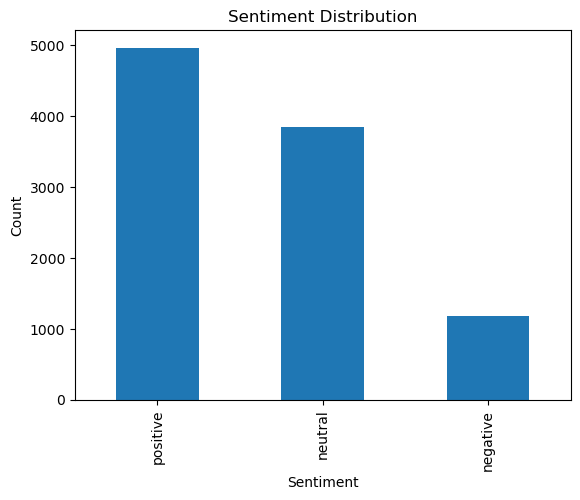

In [33]:
import matplotlib.pyplot as plt
df["pred_sen"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()